# Experiment: Draw Macro State With Split Panels

- Reuse the macro-state extraction pipeline from `draw_macro_state.ipynb`.
- For scales with state dimension less than or equal to 8, draw one subplot per variable and stitch them into one large figure.
- For scales with state dimension greater than 8, draw all variables in one axis.


In [13]:
from __future__ import annotations

import math
import re
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "src" / "models_macro.py").exists() and (candidate / "src" / "models_micro.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from src.models_macro import Parellel_Renorm_Dynamic as MacroParellelRenormDynamic
from src.models_macro import _build_windows_from_series as build_macro_windows_from_series
from src.models_micro import Parellel_Renorm_Dynamic as MicroParellelRenormDynamic
from src.models_micro import _build_windows_from_series as build_micro_windows_from_series

torch.set_grad_enabled(False)
DEFAULT_RUN_NAME = "stage2_macro"
DEFAULT_DATA_PATH = Path("loc_data_kuramoto") / "generated_data.npz"


class CompatibleMacroParellelRenormDynamic(MacroParellelRenormDynamic):
    """Allow reconstructing legacy checkpoints that keep a same-dimension macro scale."""

    def _build_scale_dims(self, reduce_dims, group):
        if getattr(self, "group_schedule", None):
            return super()._build_scale_dims(reduce_dims, group)
        reduce_dim_schedule = self._resolve_reduce_dims(reduce_dims)
        if len(reduce_dim_schedule) == 1 and int(reduce_dim_schedule[0]) == self.sym_size:
            return (
                [self.sym_size],
                [{"type": "dense", "input_dim": self.sym_size, "output_dim": self.sym_size}],
                reduce_dim_schedule,
            )
        return super()._build_scale_dims(reduce_dims, group)


In [14]:
def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "models_macro.py").exists() and (candidate / "src" / "models_micro.py").exists() and (candidate / "loc_model_stage2").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root for draw_macro_state_ts.ipynb.")


def parse_reduce_dims(value) -> List[int]:
    if value is None:
        return []
    if isinstance(value, float) and math.isnan(value):
        return []
    text = str(value).strip()
    if text == "" or text.lower() == "nan":
        return []
    return [int(part.strip()) for part in text.split(",") if part.strip()]


def parse_scale_dims(value) -> List[int]:
    return parse_reduce_dims(value)


def parse_group_schedule(value) -> List[Dict[str, object]]:
    if value is None:
        return []
    if isinstance(value, float) and math.isnan(value):
        return []
    text = str(value).strip()
    if text == "" or text.lower() == "nan":
        return []

    parts = [part.strip() for part in text.split(";") if part.strip()]
    if len(parts) < 2:
        return []

    current_groups = parse_reduce_dims(parts[0])
    if not current_groups:
        return []

    schedule: List[Dict[str, object]] = []
    current_dim = int(sum(current_groups))
    for layer_idx, part in enumerate(parts[1:], start=1):
        output_dims = parse_reduce_dims(part)
        if not output_dims:
            raise ValueError(f"group_schedule layer {layer_idx} is empty: {text}")

        if len(output_dims) == len(current_groups):
            schedule.append(
                {
                    "type": "group",
                    "macro_dim": int(sum(output_dims)),
                    "group_sizes": [int(size) for size in current_groups],
                    "group_output_dims": [int(dim) for dim in output_dims],
                }
            )
            current_groups = [int(dim) for dim in output_dims]
            current_dim = int(sum(current_groups))
            continue

        if len(output_dims) == 1:
            output_dim = int(output_dims[0])
            schedule.append(
                {
                    "type": "dense",
                    "macro_dim": output_dim,
                    "input_dim": current_dim,
                    "output_dim": output_dim,
                    "group_sizes": [int(size) for size in current_groups],
                    "group_output_dims": [output_dim],
                }
            )
            current_groups = [output_dim]
            current_dim = output_dim
            continue

        raise ValueError(
            f"group_schedule layer {layer_idx} does not match current groups {current_groups}: {part}"
        )

    return schedule


def extract_index(path: Path, pattern: str) -> Optional[int]:
    match = re.search(pattern, path.name)
    return None if match is None else int(match.group(1))


def load_array_from_path_local(path: str) -> Optional[np.ndarray]:
    file_path = Path(path)
    if not file_path.exists():
        return None
    suffix = file_path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(file_path, header=None).values.astype(np.float32)
    if suffix == ".npy":
        return np.load(file_path).astype(np.float32)
    if suffix == ".npz":
        with np.load(file_path, allow_pickle=False) as archive:
            if "data" in archive:
                return np.asarray(archive["data"], dtype=np.float32)
            if not archive.files:
                raise ValueError(f"No arrays found in npz file: {file_path}")
            return np.asarray(archive[archive.files[0]], dtype=np.float32)
    raise ValueError(f"Unsupported data file type: {file_path}")


def list_stage2_scale_artifacts(project_root: Path, run_name: str = DEFAULT_RUN_NAME) -> List[Dict]:
    model_dir = project_root / "loc_model_stage2" / run_name
    result_dir = project_root / "loc_result_stage2" / run_name
    if not model_dir.exists():
        raise FileNotFoundError(f"Missing model directory: {model_dir}")
    if not result_dir.exists():
        raise FileNotFoundError(f"Missing result directory: {result_dir}")

    model_map = {
        idx: path
        for path in sorted(model_dir.glob("model_scale*.pkl"))
        for idx in [extract_index(path, r"model_scale(\d+)\.pkl")]
        if idx is not None
    }
    summary_map = {
        idx: path
        for path in sorted(result_dir.glob("summary_scale*.csv"))
        for idx in [extract_index(path, r"summary_scale(\d+)\.csv")]
        if idx is not None
    }

    artifacts = []
    for file_scale in sorted(model_map):
        model_path = model_map[file_scale]
        summary_path = summary_map.get(file_scale)
        if summary_path is None:
            raise FileNotFoundError(f"Missing summary file for model_scale{file_scale}: {result_dir}")

        summary_row = pd.read_csv(summary_path).iloc[0].to_dict()
        logical_scale_id = int(summary_row.get("scale_id", file_scale))
        scale_dims = parse_scale_dims(summary_row.get("scale_dims", ""))
        reduce_dims = parse_reduce_dims(summary_row.get("reduce_dims", ""))
        scale_dim = None
        if scale_dims and 0 <= logical_scale_id < len(scale_dims):
            scale_dim = int(scale_dims[logical_scale_id])
        elif reduce_dims:
            if file_scale == 0 and len(reduce_dims) == 1:
                scale_dim = int(reduce_dims[0])
            elif 0 <= logical_scale_id < len(reduce_dims):
                scale_dim = int(reduce_dims[logical_scale_id])

        artifacts.append(
            {
                "file_scale": int(file_scale),
                "model_family": "macro",
                "logical_scale_id": logical_scale_id,
                "scale_dim": scale_dim,
                "scale_dims": scale_dims,
                "reduce_dims": reduce_dims,
                "group": parse_reduce_dims(summary_row.get("group", "")),
                "group_schedule": parse_group_schedule(summary_row.get("group_schedule", "")),
                "hidden_units1": int(summary_row.get("hidden_units1", 100)),
                "hidden_units2": int(summary_row.get("hidden_units2", 100)),
                "flow_num_layers": int(summary_row.get("flow_num_layers", 3)),
                "dynamics_num_layers": int(summary_row.get("dynamics_num_layers", 4)),
                "latent_size": int(summary_row.get("latent_size", 1)),
                "encoder_type": "mlp" if str(summary_row.get("encoder_type", "mlp")).strip().lower() in {"", "nan"} else str(summary_row.get("encoder_type", "mlp")).strip(),
                "time_delay": int(summary_row.get("time_delay", 1)),
                "batch_size": int(summary_row.get("batch_size", 1024)),
                "model_path": model_path,
                "summary_path": summary_path,
            }
        )

    if not artifacts:
        raise FileNotFoundError("No paired stage2 macro summary/model artifacts were found.")
    return artifacts


def load_stage2_origin_data(project_root: Path, data_path: Optional[Path] = None) -> np.ndarray:
    resolved_path = project_root / (data_path or DEFAULT_DATA_PATH)
    origin_data = load_array_from_path_local(str(resolved_path))
    if origin_data is None:
        raise FileNotFoundError(f"Could not load origin data from: {resolved_path}")
    return np.asarray(origin_data, dtype=np.float32)


def build_state_windows(origin_data: np.ndarray, time_delay: int, model_family: str, max_samples: Optional[int] = None, use_train_split: bool = True) -> Tuple[np.ndarray, np.ndarray]:
    window_builder = build_micro_windows_from_series if model_family == "micro" else build_macro_windows_from_series
    x_all, y_all = window_builder(origin_data, int(time_delay))
    if use_train_split:
        train_end = max(1, int(len(x_all) * 0.95))
        x_all = x_all[:train_end]
        y_all = y_all[:train_end]
    if max_samples is not None:
        max_samples = int(max_samples)
        x_all = x_all[:max_samples]
        y_all = y_all[:max_samples]
    if len(x_all) == 0:
        raise ValueError("No windows were generated for macro state extraction.")
    return x_all.astype(np.float32), y_all.astype(np.float32)


def build_state_model(num_nodes: int, artifact: dict, device: torch.device):
    model_cls = MicroParellelRenormDynamic if artifact["model_family"] == "micro" else CompatibleMacroParellelRenormDynamic
    model = model_cls(
        sym_size=int(num_nodes),
        latent_size=int(artifact["latent_size"]),
        effect_size=int(num_nodes),
        cut_size=2,
        hidden_units1=int(artifact["hidden_units1"]),
        hidden_units2=int(artifact["hidden_units2"]),
        normalized_state=True,
        device=device,
        is_random=False,
        flow_num_layers=int(artifact["flow_num_layers"]),
        dynamics_num_layers=int(artifact["dynamics_num_layers"]),
        decode_noise_scale=0.0,
        reduce_dims=artifact["reduce_dims"],
        group=artifact["group"],
        group_schedule=artifact["group_schedule"],
        encoder_type=artifact["encoder_type"],
    ).to(device)
    state_dict = torch.load(artifact["model_path"], map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def extract_current_inputs(x_windows: np.ndarray) -> np.ndarray:
    if x_windows.ndim == 3:
        return np.asarray(x_windows[:, 0], dtype=np.float32)
    if x_windows.ndim == 2:
        return np.asarray(x_windows, dtype=np.float32)
    raise ValueError(f"x_windows must have shape [B, T, N] or [B, N], but got {x_windows.shape}")


def compute_macro_state_for_scale(
    artifact: dict,
    origin_data: np.ndarray,
    device: Union[str, torch.device] = "cpu",
    max_samples: Optional[int] = None,
    use_train_split: bool = True,
):
    device = torch.device(device)
    model = build_state_model(origin_data.shape[-1], artifact, device=device)
    x_np, _ = build_state_windows(
        origin_data,
        time_delay=artifact["time_delay"],
        model_family=artifact["model_family"],
        max_samples=max_samples,
        use_train_split=use_train_split,
    )
    source_np = extract_current_inputs(x_np)
    source_tensor = torch.tensor(source_np, dtype=torch.float32, device=device)
    macro_states = model.encoding1(source_tensor, artifact["logical_scale_id"])[artifact["logical_scale_id"]]
    return {
        **artifact,
        "num_windows": int(len(x_np)),
        "num_samples": int(len(source_np)),
        "input_dim": int(source_np.shape[-1]),
        "macro_states": macro_states.detach().cpu().numpy(),
    }


def save_macro_state_results(
    results: List[Dict],
    output_dir: Path,
    file_name_template: str = "macro_state_scale{file_scale}.csv",
) -> List[Path]:
    output_dir.mkdir(parents=True, exist_ok=True)
    saved_paths = []
    for item in results:
        columns = [f"macro_state_{idx}" for idx in range(item["macro_states"].shape[1])]
        output_path = output_dir / file_name_template.format(file_scale=item["file_scale"])
        pd.DataFrame(item["macro_states"], columns=columns).to_csv(output_path, index=False)
        saved_paths.append(output_path)
    return saved_paths


def compute_macro_states_for_all_scales(
    project_root: Optional[Path] = None,
    run_name: str = DEFAULT_RUN_NAME,
    data_path: Optional[Path] = None,
    device: Union[str, torch.device] = "cpu",
    max_samples: Optional[int] = None,
    use_train_split: bool = True,
    output_dir: Optional[Path] = None,
):
    project_root = find_project_root(project_root)
    origin_data = load_stage2_origin_data(project_root, data_path=data_path)
    artifacts = list_stage2_scale_artifacts(project_root, run_name=run_name)
    results = [
        compute_macro_state_for_scale(
            artifact,
            origin_data,
            device=device,
            max_samples=max_samples,
            use_train_split=use_train_split,
        )
        for artifact in artifacts
    ]

    if output_dir is None:
        output_dir = project_root / "loc_result_stage2" / run_name / "draw_macro_state_ts"
    output_dir = Path(output_dir)
    state_paths = save_macro_state_results(results, output_dir=output_dir)

    summary_rows = []
    for item, state_path in zip(results, state_paths):
        summary_rows.append(
            {
                "file_scale": item["file_scale"],
                "model_family": item["model_family"],
                "logical_scale_id": item["logical_scale_id"],
                "scale_dim": item["scale_dim"],
                "time_delay": item["time_delay"],
                "num_windows": item["num_windows"],
                "num_samples": item["num_samples"],
                "input_dim": item["input_dim"],
                "state_dim": int(item["macro_states"].shape[1]),
                "model_path": str(item["model_path"].resolve()),
                "summary_path": str(item["summary_path"].resolve()),
                "macro_state_csv": str(state_path.resolve()),
            }
        )
    return pd.DataFrame(summary_rows).sort_values("file_scale").reset_index(drop=True), results


In [25]:
PROJECT_ROOT = find_project_root()
STATE_SUMMARY_DF, STATE_RESULTS = compute_macro_states_for_all_scales(
    project_root=PROJECT_ROOT,
    run_name=DEFAULT_RUN_NAME,
    data_path=DEFAULT_DATA_PATH,
    device="cpu",
    max_samples=20000,
    use_train_split=True,
)
STATE_SUMMARY_DF


,file_scale,model_family,logical_scale_id,scale_dim,time_delay,num_windows,num_samples,input_dim,state_dim,model_path,summary_path,macro_state_csv
0,1,macro,0,16,3,18998,18998,32,16,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
1,2,macro,1,2,3,18998,18998,32,2,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
2,3,macro,2,1,3,18998,18998,32,1,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...


In [26]:
state_shape_summary = pd.DataFrame(
    [
        {
            "file_scale": item["file_scale"],
            "model_family": item["model_family"],
            "logical_scale_id": item["logical_scale_id"],
            "scale_dim": item["scale_dim"],
            "num_samples": item["num_samples"],
            "state_dim": item["macro_states"].shape[1],
        }
        for item in STATE_RESULTS
    ]
).sort_values("file_scale").reset_index(drop=True)
state_shape_summary


,file_scale,model_family,logical_scale_id,scale_dim,num_samples,state_dim
0,1,macro,0,16,18998,16
1,2,macro,1,2,18998,2
2,3,macro,2,1,18998,1


In [27]:
for item in STATE_RESULTS:
    preview_df = pd.DataFrame(
        item["macro_states"],
        columns=[f"macro_state_{idx}" for idx in range(item["macro_states"].shape[1])],
    ).head()
    print(
        f"file_scale={item['file_scale']} | "
        f"model_family={item['model_family']} | "
        f"logical_scale_id={item['logical_scale_id']} | "
        f"state_dim={item['macro_states'].shape[1]}"
    )
    display(preview_df)


file_scale=1 | model_family=macro | logical_scale_id=0 | state_dim=16


,macro_state_0,macro_state_1,macro_state_2,macro_state_3,macro_state_4,macro_state_5,macro_state_6,macro_state_7,macro_state_8,macro_state_9,macro_state_10,macro_state_11,macro_state_12,macro_state_13,macro_state_14,macro_state_15
0,-0.419169,-0.508296,-0.607385,-0.360497,-1.043143,0.844686,-0.995709,0.853907,-0.880063,-0.256636,0.777252,0.281235,-0.565626,0.670745,-0.583010,0.803537
1,-0.419236,-0.508459,-0.607438,-0.360493,-1.043081,0.844658,-0.995946,0.854073,-0.880056,-0.256613,0.777126,0.281404,-0.565448,0.670517,-0.582696,0.803323
2,-0.419321,-0.508645,-0.607464,-0.360518,-1.043003,0.844631,-0.996191,0.854238,-0.880022,-0.256594,0.776993,0.281559,-0.565257,0.670279,-0.582374,0.803090
3,-0.419397,-0.508827,-0.607485,-0.360532,-1.042910,0.844591,-0.996421,0.854395,-0.879968,-0.256553,0.776841,0.281705,-0.565066,0.670030,-0.582040,0.802841
4,-0.419474,-0.508999,-0.607487,-0.360539,-1.042832,0.844552,-0.996658,0.854537,-0.879921,-0.256522,0.776703,0.281856,-0.564891,0.669782,-0.581708,0.802596


file_scale=2 | model_family=macro | logical_scale_id=1 | state_dim=2


,macro_state_0,macro_state_1
0,-0.563019,-0.579966
1,-0.563044,-0.579815
2,-0.563074,-0.579653
3,-0.563093,-0.579486
4,-0.563109,-0.579324


file_scale=3 | model_family=macro | logical_scale_id=2 | state_dim=1


,macro_state_0
0,-0.596001
1,-0.595957
2,-0.595910
3,-0.595852
4,-0.595793


/tmp/ipykernel_42589/3604352345.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(state_dim, 1))


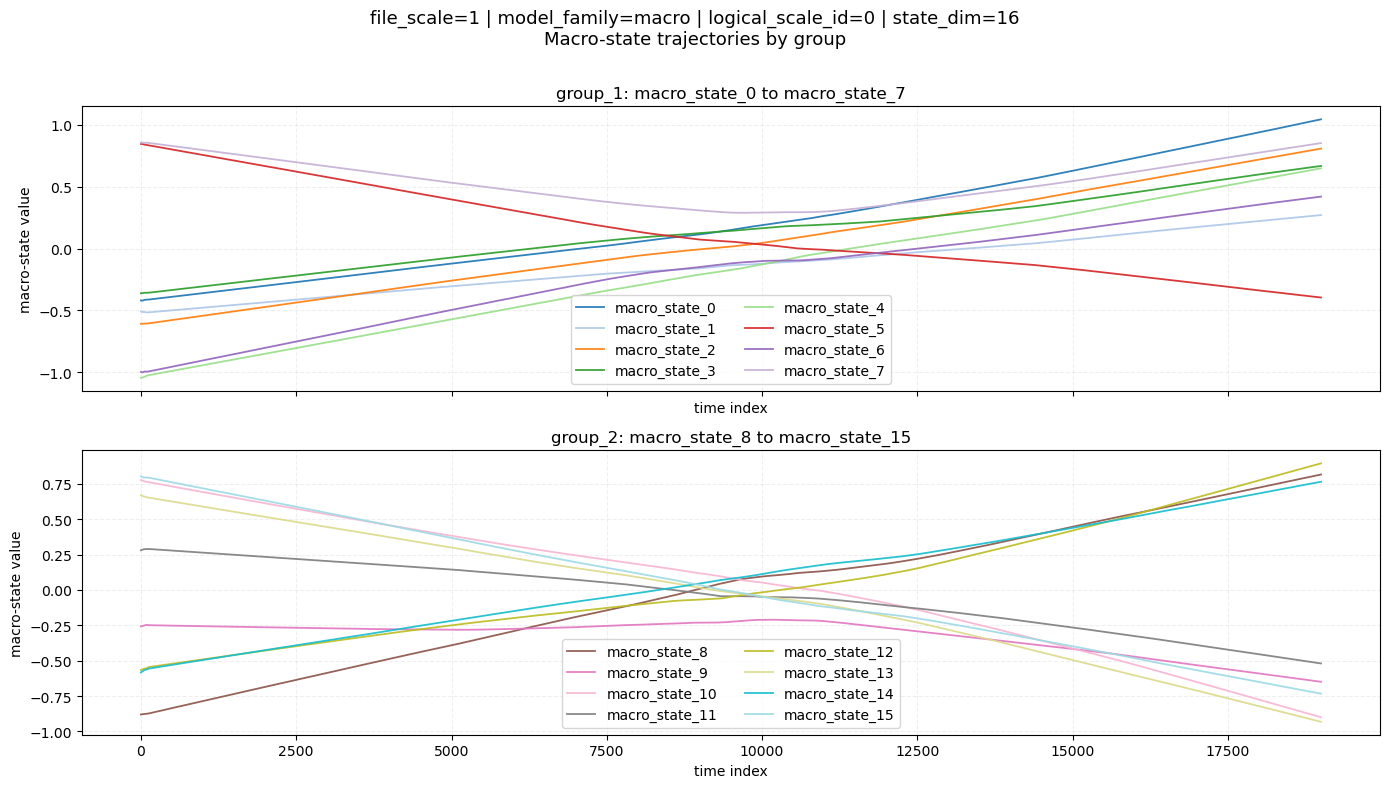

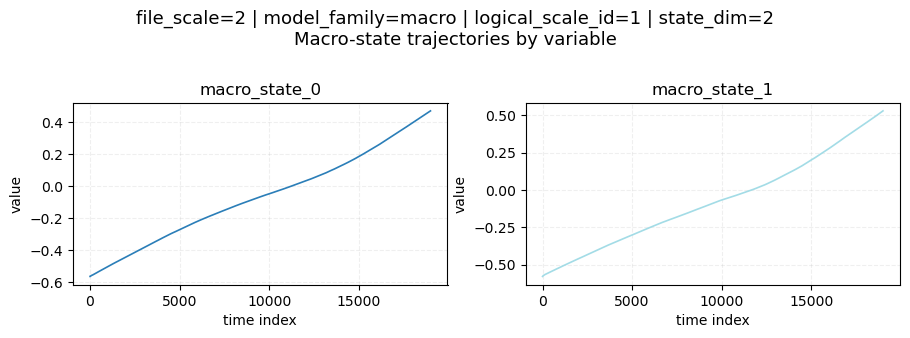

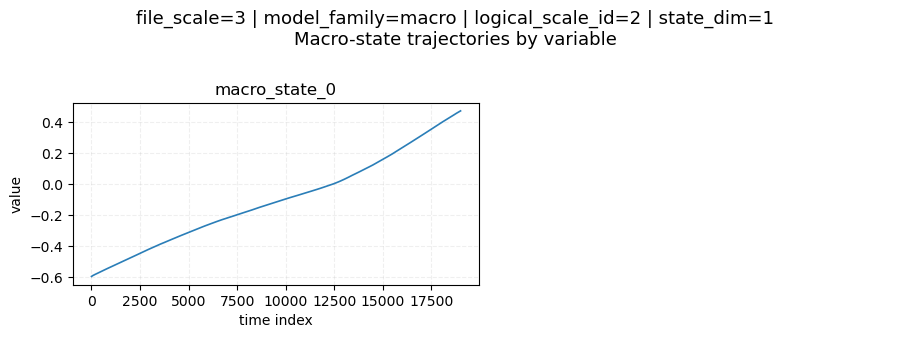

,file_scale,model_family,logical_scale_id,state_dim,plot_mode,plot_path
0,1,macro,0,16,group_rows,/home/wangzhipeng/code/causal_network/causal_n...
1,2,macro,1,2,split_panels,/home/wangzhipeng/code/causal_network/causal_n...
2,3,macro,2,1,split_panels,/home/wangzhipeng/code/causal_network/causal_n...


In [28]:
PLOT_OUTPUT_DIR = PROJECT_ROOT / "loc_result_stage2" / DEFAULT_RUN_NAME / "draw_macro_state_ts" / "time_series_plots"
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _resolve_subplot_grid(num_panels: int) -> Tuple[int, int]:
    num_panels = int(num_panels)
    if num_panels <= 0:
        raise ValueError("num_panels must be positive")
    ncols = 2 if num_panels <= 4 else 3 if num_panels <= 9 else 4
    nrows = math.ceil(num_panels / ncols)
    return nrows, ncols


def _resolve_group_row_slices(item: Dict, state_dim: int) -> List[Tuple[int, int]]:
    logical_scale_id = int(item.get("logical_scale_id", -1))
    group_schedule = item.get("group_schedule") or []
    if logical_scale_id < 0 or logical_scale_id >= len(group_schedule):
        return []

    scale_spec = group_schedule[logical_scale_id]
    if str(scale_spec.get("type", "")).strip().lower() != "group":
        return []

    output_dims = [int(dim) for dim in scale_spec.get("group_output_dims", []) if int(dim) > 0]
    if len(output_dims) <= 1 or int(sum(output_dims)) != int(state_dim):
        return []

    slices = []
    start = 0
    for output_dim in output_dims:
        end = start + int(output_dim)
        slices.append((start, end))
        start = end
    return slices


def plot_macro_state_timeseries(
    item: Dict,
    output_dir: Optional[Path] = None,
    max_points: Optional[int] = 2048,
    split_threshold: int = 8,
):
    states = np.asarray(item["macro_states"], dtype=np.float32)
    if states.ndim != 2:
        raise ValueError(f"macro_states must have shape [B, D], but got {states.shape}")

    if max_points is not None and len(states) > int(max_points):
        states = states[: int(max_points)]

    time_axis = np.arange(states.shape[0])
    state_dim = int(states.shape[1])
    title = (
        f"file_scale={item['file_scale']} | "
        f"model_family={item['model_family']} | "
        f"logical_scale_id={item['logical_scale_id']} | "
        f"state_dim={state_dim}"
    )
    cmap = plt.cm.get_cmap("tab20", max(state_dim, 1))
    group_row_slices = _resolve_group_row_slices(item, state_dim)

    if group_row_slices and state_dim > int(split_threshold):
        num_groups = len(group_row_slices)
        fig, axes = plt.subplots(
            nrows=num_groups,
            ncols=1,
            figsize=(14, 3.6 * num_groups + 0.8),
            sharex=True,
            squeeze=False,
        )
        axes_flat = axes.flatten()

        for group_idx, (ax, group_slice) in enumerate(zip(axes_flat, group_row_slices), start=1):
            start_idx, end_idx = group_slice
            for dim_idx in range(start_idx, end_idx):
                ax.plot(
                    time_axis,
                    states[:, dim_idx],
                    linewidth=1.3,
                    alpha=0.92,
                    color=cmap(dim_idx % cmap.N),
                    label=f"macro_state_{dim_idx}",
                )
            ax.set_title(f"group_{group_idx}: macro_state_{start_idx} to macro_state_{end_idx - 1}")
            ax.set_ylabel("macro-state value")
            ax.grid(alpha=0.2, linestyle="--", linewidth=0.8)
            group_dim = int(end_idx - start_idx)
            if group_dim <= 8:
                ax.legend(loc="best", ncol=2 if group_dim > 4 else 1)
            else:
                ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False, ncol=1)

        for ax in axes_flat:
            ax.set_xlabel("time index")

        fig.suptitle(f"{title}\nMacro-state trajectories by group", fontsize=13)
        fig.tight_layout(rect=(0, 0, 1, 0.97))
        plot_mode = "group_rows"
    elif state_dim <= int(split_threshold):
        nrows, ncols = _resolve_subplot_grid(state_dim)
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(4.6 * ncols, 2.6 * nrows + 0.8),
            sharex=True,
            squeeze=False,
        )
        axes_flat = axes.flatten()

        for dim_idx in range(state_dim):
            ax = axes_flat[dim_idx]
            ax.plot(
                time_axis,
                states[:, dim_idx],
                linewidth=1.2,
                alpha=0.95,
                color=cmap(dim_idx % cmap.N),
            )
            ax.set_title(f"macro_state_{dim_idx}")
            ax.set_ylabel("value")
            ax.grid(alpha=0.2, linestyle="--", linewidth=0.8)

        for extra_ax in axes_flat[state_dim:]:
            extra_ax.axis("off")

        for ax in axes_flat[:state_dim]:
            ax.set_xlabel("time index")

        fig.suptitle(f"{title}\nMacro-state trajectories by variable", fontsize=13)
        fig.tight_layout(rect=(0, 0, 1, 0.97))
        plot_mode = "split_panels"
    else:
        fig_width = 12 if state_dim <= 12 else 14
        fig_height = 4.5 if state_dim <= 12 else 6.0
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        for dim_idx in range(state_dim):
            ax.plot(
                time_axis,
                states[:, dim_idx],
                linewidth=1.6 if state_dim <= 12 else 1.1,
                alpha=0.9,
                color=cmap(dim_idx % cmap.N),
                label=f"macro_state_{dim_idx}",
            )
        
        ax.set_title(f"{title}\nMacro-state trajectories over time")
        ax.set_xlabel("time index")
        ax.set_ylabel("macro-state value")
        ax.grid(alpha=0.2, linestyle="--")

        if state_dim <= 12:
            ax.legend(loc="best", ncol=2 if state_dim > 6 else 1)
        else:
            ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False, ncol=1)

        fig.tight_layout()
        plot_mode = "single_axis"

    saved_path = None
    if output_dir is not None:
        saved_path = Path(output_dir) / f"macro_state_timeseries_scale{item['file_scale']}.png"
        fig.savefig(saved_path, dpi=180, bbox_inches="tight")

    plt.show()
    plt.close(fig)
    return saved_path, plot_mode


plot_summary = []
for item in STATE_RESULTS:
    saved_path, plot_mode = plot_macro_state_timeseries(
        item,
        output_dir=PLOT_OUTPUT_DIR,
        max_points=20000,
        split_threshold=8,
    )
    plot_summary.append(
        {
            "file_scale": item["file_scale"],
            "model_family": item["model_family"],
            "logical_scale_id": item["logical_scale_id"],
            "state_dim": item["macro_states"].shape[1],
            "plot_mode": plot_mode,
            "plot_path": None if saved_path is None else str(saved_path.resolve()),
        }
    )

pd.DataFrame(plot_summary).sort_values("file_scale").reset_index(drop=True)